# Eksperyment: Wpływ funkcji aktywacji na wyniki MLP

W tym notatniku zbadamy wpływ funkcji aktywacji (`sigmoid`, `gelu`, `identity`) na proces uczenia modelu MLP. Notatnik jest skonfigurowany do obsługi zarówno zadań **klasyfikacji** (np. XOR), jak i **regresji** (np. dopasowanie do funkcji). 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp import MLP
# Dodano accuracy, mse, plot_predictions
from mlp.utils import plot_loss, plot_weight_evolution, plot_decision_boundary, train_test_split, accuracy, mse, plot_predictions

# Konfiguracja
SEED = 44
np.random.seed(SEED)

# === KONFIGURACJA EKSPERYMENTU ===
# Odkomentuj jeden z bloków, aby wybrać zadanie

# --- BLOK 1: Klasyfikacja (Oryginalny problem XOR) ---
TASK = "multiclass" # Użyj "multiclass" dla wyjścia [N, 2] lub "binary" dla [N, 1]
CSV_PATH = "../lab1_data/Classification/data.noisyXOR.train.1000.csv"
FEATURE_COLS = ["x", "y"]
TARGET_COL = "cls"
# Przekształca etykiety (np. {1, 2} -> {0, 1})
TARGET_PREP = lambda y: (y - 1).reshape(-1, 1) 
LAYER_SIZES = [2, 32, 2] # Wejście 2D (x, y), Wyjście 2 (dla 2 klas)

# # --- BLOK 2: Regresja (Przykład) ---
TASK = "regression"
CSV_PATH = "../lab1_data/Regression/data.activation.train.1000.csv"
FEATURE_COLS = ["x"]
TARGET_COL = "y"
TARGET_PREP = lambda y: y.reshape(-1, 1)
LAYER_SIZES = [1, 32, 1] # Wejście 1D (x), Wyjście 1D (y)


config = {
    "epochs": 500,
    "learning_rate": 0.001,
    # "use_bias": True, 
}

activations = ["sigmoid", "gelu", "identity"]

## Wczytanie i wizualizacja danych

          x           y
0  3.180650  -11.975601
1  4.509115   -3.256370
2  2.541621  -21.890366
3 -1.657136 -251.980642
4 -0.983170 -218.305912


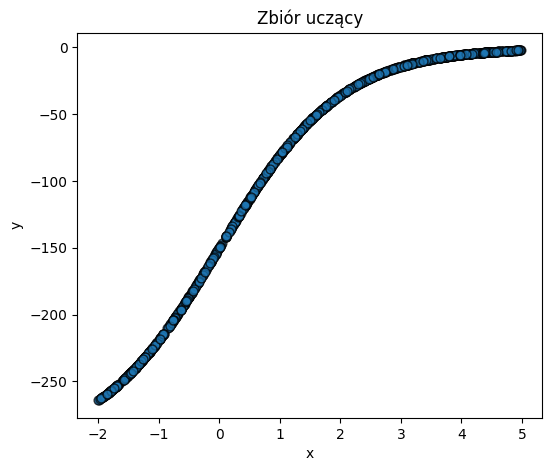

In [46]:
data = pd.read_csv(CSV_PATH)
print(data.head())

X = data[FEATURE_COLS].values
y = TARGET_PREP(data[TARGET_COL].values)

plt.figure(figsize=(6, 5))

if X.shape[1] == 2:
    # Wizualizacja 2D (jak w XOR), kolorowana przez etykietę/wartość
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="tab10", s=40, edgecolors="k")
    plt.xlabel(FEATURE_COLS[0])
    plt.ylabel(FEATURE_COLS[1])
elif X.shape[1] == 1:
    # Wizualizacja 1D (jak w regresji x->y)
    plt.scatter(X[:, 0], y.ravel(), s=40, edgecolors="k", alpha=0.7)
    plt.xlabel(FEATURE_COLS[0])
    plt.ylabel(TARGET_COL)
            
plt.title("Zbiór uczący")
plt.show()

## Trening modeli dla różnych funkcji aktywacji

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=SEED)

print(f"Całkowity zbiór: {len(X)} próbek")
print(f"Zbiór treningowy: {len(X_train)} próbek")
print(f"Zbiór testowy: {len(X_test)} próbek")

results = {}

for act in activations:
    print(f"\n=== Trening dla aktywacji: {act} (Zadanie: {TASK}) ===")
    model = MLP(
        layer_sizes=LAYER_SIZES, 
        task=TASK,               
        activation=act,
        learning_rate=config["learning_rate"],
        seed=SEED,
    )

    losses, weight_hist = model.fit(X_train, y_train, epochs=config["epochs"], verbose=False)

    preds = model.predict(X_test)
    
    # Warunkowe obliczanie metryki
    if TASK == "regression":
        metric = mse(y_test, preds)
        metric_name = "MSE (TEST)"
    else:
        metric = accuracy(y_test, preds)
        metric_name = "Dokładność (TEST)"

    results[act] = {
        "model": model,
        "losses": losses,       # Historia strat treningowych
        "weights": weight_hist, # Historia wag
        "metric": metric,       # Metryka testowa (Acc lub MSE)
        "metric_name": metric_name
    }


    print(f"Końcowa strata (trening): {losses[-1]:.6f} | {metric_name}: {metric:.4f}")

Całkowity zbiór: 1000 próbek
Zbiór treningowy: 700 próbek
Zbiór testowy: 300 próbek

=== Trening dla aktywacji: sigmoid (Zadanie: regression) ===
Końcowa strata (trening): 43.090242 | MSE (TEST): 48.9036

=== Trening dla aktywacji: gelu (Zadanie: regression) ===
Końcowa strata (trening): 9.450091 | MSE (TEST): 10.2835

=== Trening dla aktywacji: identity (Zadanie: regression) ===
Końcowa strata (trening): 712.197747 | MSE (TEST): 694.9990


## Wizualizacja wyników


### Funkcja aktywacji: sigmoid


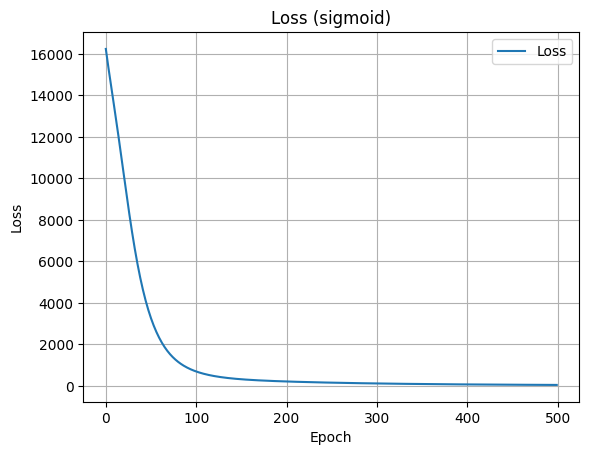

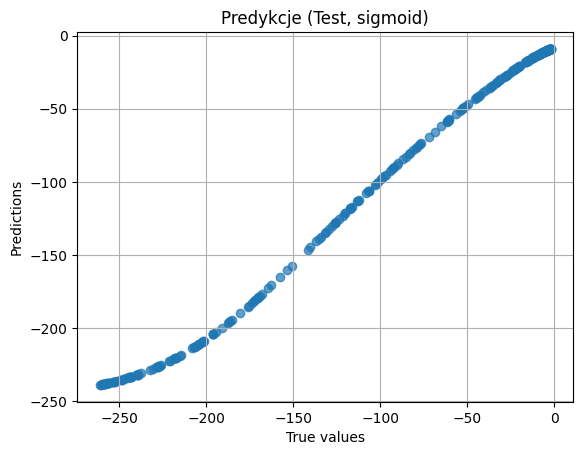

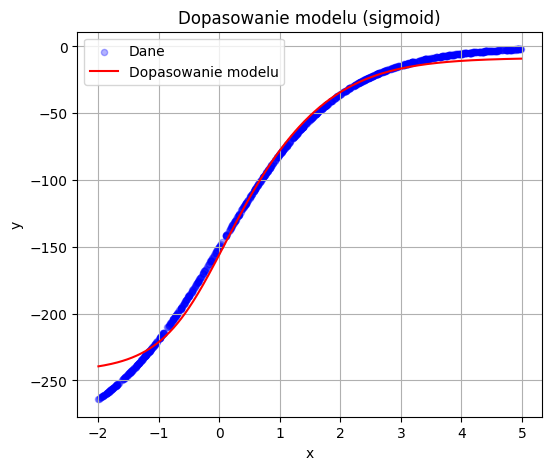

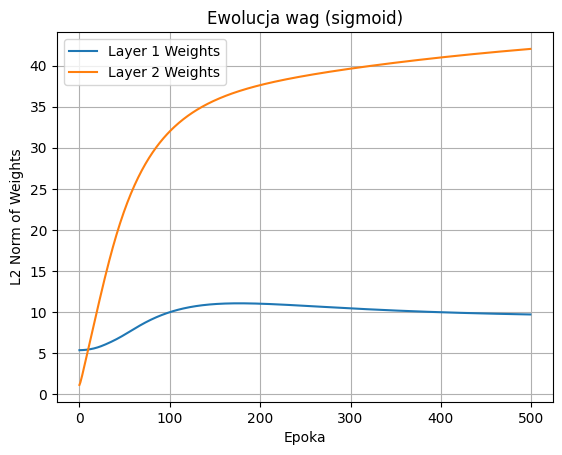


### Funkcja aktywacji: gelu


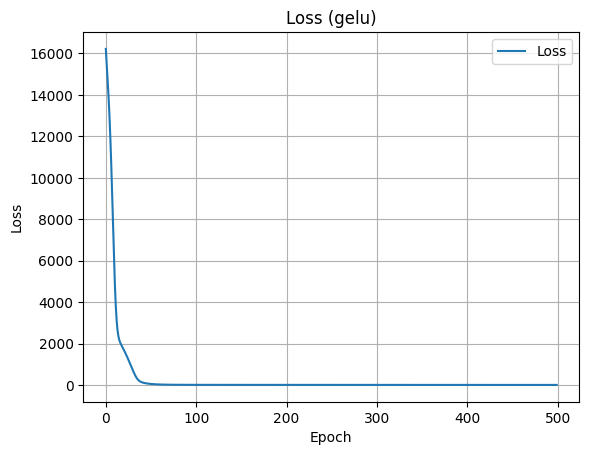

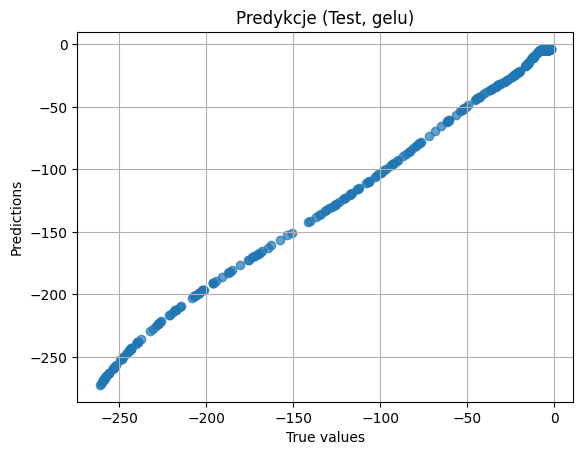

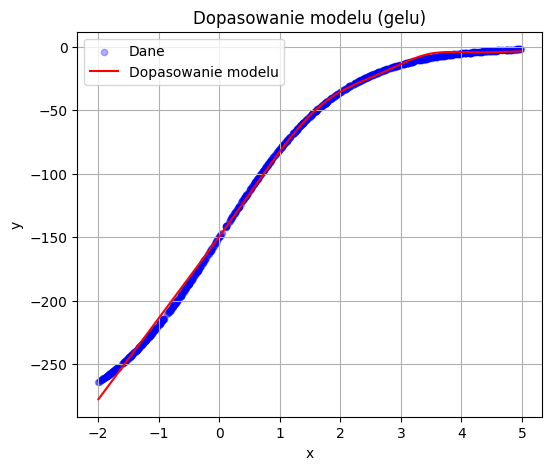

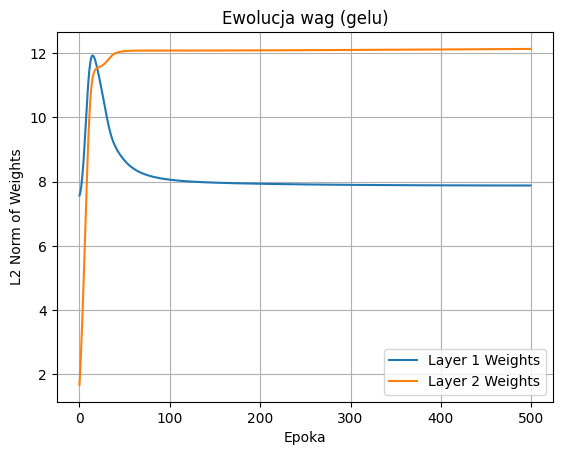


### Funkcja aktywacji: identity


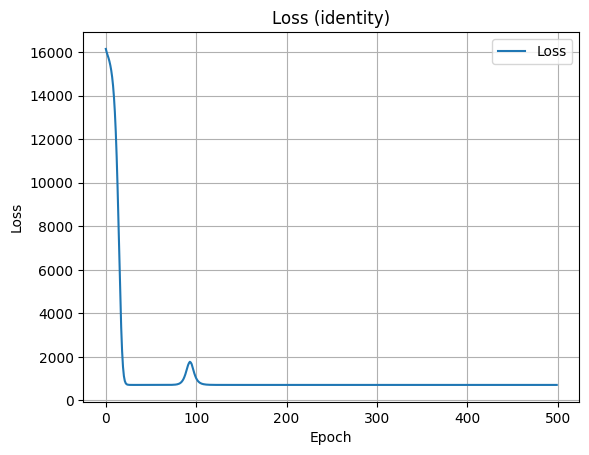

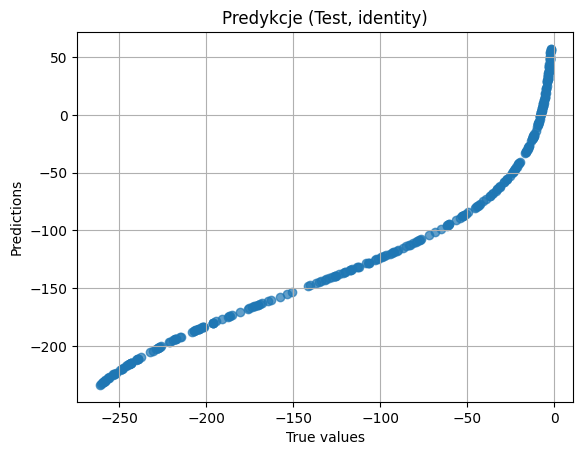

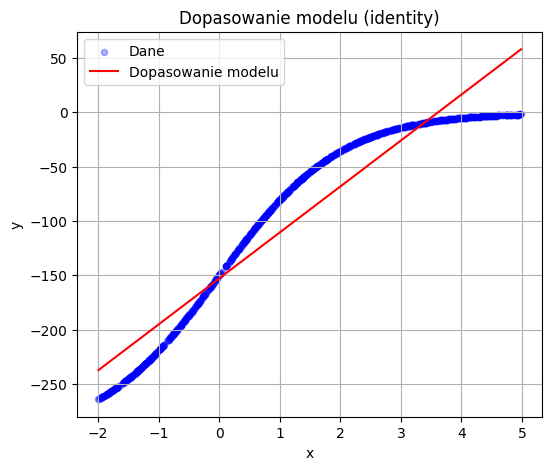

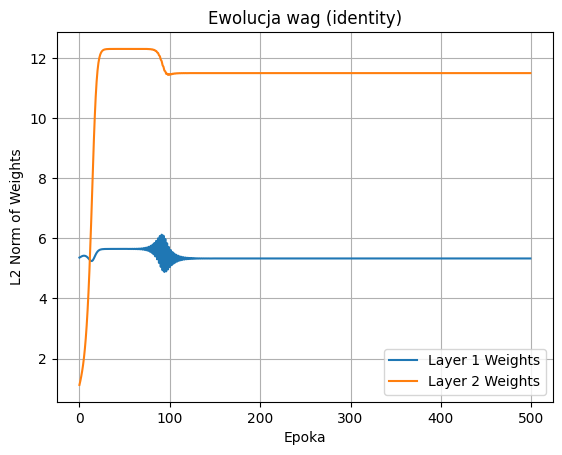

In [48]:
for act, data in results.items():
    print(f"\n### Funkcja aktywacji: {act}")
    
    # 1. Wykres straty (wspólny)
    plot_loss(data["losses"], title=f"Loss ({act})")
    
    # 2. Wykres specyficzny dla zadania (Granica decyzyjna / Predykcje)
    task_type = data["model"].task
    
    if task_type == "regression":
        if X.shape[1] == 1:
            # Dla regresji 1D, pokaż predykcje vs rzeczywiste na zbiorze testowym
            preds_test = data["model"].predict(X_test)
            plot_predictions(y_test, preds_test, title=f"Predykcje (Test, {act})")
            
            # Pokaż dopasowanie modelu do całego zbioru X
            plt.figure(figsize=(6, 5))
            plt.scatter(X, y, color="blue", label="Dane", alpha=0.3, s=20)
            # Sortowanie X dla ładnego wykresu linii
            X_sorted_idx = np.argsort(X.ravel())
            X_sorted = X[X_sorted_idx]
            preds_all_sorted = data["model"].predict(X_sorted)
            plt.plot(X_sorted, preds_all_sorted, color="red", label="Dopasowanie modelu")
            plt.title(f"Dopasowanie modelu ({act})")
            plt.xlabel(FEATURE_COLS[0])
            plt.ylabel(TARGET_COL)
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print(f"Wizualizacja regresji obsługiwana tylko dla 1 cechy wejściowej (X). Pomięto wykres predykcji dla {act}.")
    
    else: # "binary" or "multiclass"
        if X.shape[1] == 2:
            # Dla klasyfikacji 2D, pokaż granicę decyzyjną
            # (Używamy całego zbioru X, y do wizualizacji granicy)
            plot_decision_boundary(data["model"], X, y, title=f"Granica decyzyjna ({act})")
        else:
            print(f"Wizualizacja granicy decyzyjnej obsługiwana tylko dla 2 cech wejściowych (X). Pomięto wykres dla {act}.")
    
    # 3. Wykres ewolucji wag (wspólny)
    plot_weight_evolution(data["weights"], title=f"Ewolucja wag ({act})")

## Podsumowanie

Eksperymenty zmieniając `LAYER_SIZES`, `epochs`, `learning_rate` oraz przełączając `TASK`.